# PREDICCIÓN DE CARRERAS ESTUDIANTILES - METODOLOGÍA CRISP-DM

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Librerías adicionales para optimización
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


# FASE 1: BUSINESS UNDERSTANDING (Entendimiento del Negocio)

OBJETIVO: Predecir qué carrera elegirá un estudiante basado en sus características
demográficas, socioeconómicas y de acceso tecnológico.

# FASE 2: DATA UNDERSTANDING (Entendimiento de los Datos):

In [3]:
file_path = "/content/drive/MyDrive/3er Ciclo Big Data/Inscripción ImpulsaT - TECAZUAY (respuestas) (1).xlsx"
df = pd.read_excel(file_path)

# Información básica del dataset

In [4]:
df.head()

,Marca temporal,Cédula/Pasaporte:\n,Apellidos:,Nombres:,Correo electrónico,Número de celular,Fecha de nacimiento:,Sexo:,Tipo de Sangre:,ESTADO CIVIL:,...,Tiene de Discapacidad:,Tipo de discapacidad:,Porcentaje de discapacidad:,Número de carnet:,Enfermedad Catastrófica:,País de Nacimiento,Cantón de Nacimiento,Dispones de computador y acceso a internet para recibir las clases de forma virtual?,¿En cuál de las carreras que ofrece nuestro instituto estás interesado en estudiar?,OBSERVACIONES
0,2025-06-12 08:53:25.902,0704236942,Villegas Ugarte,Miguel Andrés,migvill88@gmail.com,0959819754,1988-06-13,Hombre,ORH (+),Casado,...,No,NaN,NaN,NaN,No,Ecuador,Machala,Sí,ADMINISTRACION DE INFRAESTRUCTURA Y PLATAFORMA...,ok
1,2025-06-12 19:27:12.928,0107521171,Pindo Quulli,Danny Esteban,estebanpindo@gmail.com,0967233740,2007-05-13,Hombre,ORH (+),Soltero,...,No,NaN,NaN,NaN,No,Ecuador,Cuenca,No,ADMINISTRACION DE INFRAESTRUCTURA Y PLATAFORMA...,ok
2,2025-06-12 10:14:05.226,0107855413,Ramón Tene,Michelle Fernanda,ramonmishell2525@gmail.com,0983895087,2006-01-10,Mujer,ORH (+),Soltero,...,No,NaN,NaN,NaN,No,Ecuador,Cuenca,Sí,BIG DATA,ok
3,2025-06-12 08:07:12.594,0150266708,Guamán Agudo,Vanessa Leonela,vaneguaman10@gmail.com,0987975117,2007-12-10,Mujer,ORH (+),Soltero,...,No,NaN,NaN,NaN,No,Ecuador,Cuenca,Sí,CIBERSEGURIDAD,ok
4,2025-06-12 11:33:33.409,0107571234,Mayllazhungo Pañi,Jenyfer estefany,estefanyjenyfer90@gmail.com,0982729626,2007-09-28,Mujer,ORH (+),Soltero,...,No,NaN,NaN,NaN,Sí,Ecuador,Cuenca,No,CIBERSEGURIDAD,ok


In [5]:
# Ver columnas
print(df.columns.tolist())


['Marca temporal', 'Cédula/Pasaporte:\n', 'Apellidos:', 'Nombres:', 'Correo electrónico', 'Número de celular', 'Fecha de nacimiento:', 'Sexo:', 'Tipo de Sangre:', 'ESTADO CIVIL:', 'ETNIA:', 'Tiene de Discapacidad: ', 'Tipo de discapacidad:', 'Porcentaje de discapacidad:', 'Número de carnet:', 'Enfermedad Catastrófica:', 'País de Nacimiento', 'Cantón de Nacimiento', 'Dispones de computador y acceso a internet para recibir las clases de forma virtual?', '¿En cuál de las carreras que ofrece nuestro instituto estás interesado en estudiar? ', 'OBSERVACIONES']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 21 columns):
 #   Column                                                                                Non-Null Count  Dtype         
---  ------                                                                                --------------  -----         
 0   Marca temporal                                                                        516 non-null    datetime64[ns]
 1   Cédula/Pasaporte:
                                                                    516 non-null    object        
 2   Apellidos:                                                                            516 non-null    object        
 3   Nombres:                                                                              516 non-null    object        
 4   Correo electrónico                                                                    516 non-null    object        
 5   Número de celular                   

In [7]:
df.isnull().sum()

,0
Marca temporal,0
Cédula/Pasaporte:\n,0
Apellidos:,0
Nombres:,0
Correo electrónico,0
Número de celular,0
Fecha de nacimiento:,0
Sexo:,0
Tipo de Sangre:,0
ESTADO CIVIL:,0


In [8]:
# Análisis de la variable objetivo
carrera_col = '¿En cuál de las carreras que ofrece nuestro instituto estás interesado en estudiar? '
df[carrera_col].value_counts()

,count
¿En cuál de las carreras que ofrece nuestro instituto estás interesado en estudiar?,
CONTABILIDAD,95
EDUCACION INICIAL,65
MECATRONICA,64
DESARROLLO DE SOFTWARE,59
MANTENIMIENTO ELECTRICO Y CONTROL INDUSTRIAL,51
ENTRENAMIENTO DEPORTIVO,46
CIBERSEGURIDAD,29
METALMECANICA,28
TRIBUTACION,15


# FASE 3: DATA PREPARATION (Preparación de los Datos)

In [9]:
# Crear copia para trabajar
df_clean = df.copy()

In [10]:
# Limpieza de nombres de columnas
df_clean.columns = [col.strip().replace('\n', '') for col in df_clean.columns]

In [11]:
# Renombrar columnas para mayor claridad
column_mapping = {
    'Cédula/Pasaporte:': 'cedula',
    'Apellidos:': 'apellidos',
    'Nombres:': 'nombres',
    'Correo electrónico': 'email',
    'Número de celular': 'telefono',
    'Fecha de nacimiento:': 'fecha_nacimiento',
    'Sexo:': 'sexo',
    'Tipo de Sangre:': 'tipo_sangre',
    'ESTADO CIVIL:': 'estado_civil',
    'ETNIA:': 'etnia',
    'Tiene de Discapacidad:': 'tiene_discapacidad',
    'Tipo de discapacidad:': 'tipo_discapacidad',
    'Porcentaje de discapacidad:': 'porcentaje_discapacidad',
    'Número de carnet:': 'numero_carnet',
    'Enfermedad Catastrófica:': 'enfermedad_catastrofica',
    'País de Nacimiento': 'pais_nacimiento',
    'Cantón de Nacimiento': 'canton_nacimiento',
    'Dispones de computador y acceso a internet para recibir las clases de forma virtual?': 'acceso_tecnologia',
    '¿En cuál de las carreras que ofrece nuestro instituto estás interesado en estudiar?': 'carrera_interes'
}

df_clean.rename(columns=column_mapping, inplace=True)

In [13]:
# Procesamiento de fechas y cálculo de edad
df_clean['fecha_nacimiento'] = pd.to_datetime(df_clean['fecha_nacimiento'], errors='coerce')
fecha_actual = datetime.now()
df_clean['edad'] = (fecha_actual - df_clean['fecha_nacimiento']).dt.days // 365


In [14]:
# Creación de variables derivadas
def crear_grupo_edad(edad):
    if edad <= 18:
        return 'Menor_18'
    elif edad <= 25:
        return '18_25'
    elif edad <= 35:
        return '25_35'
    else:
        return 'Mayor_35'

def crear_generacion(edad):
    if edad <= 27:
        return 'Gen_Z'
    elif edad <= 42:
        return 'Millennial'
    else:
        return 'Gen_X_Plus'

df_clean['grupo_edad'] = df_clean['edad'].apply(crear_grupo_edad)
df_clean['generacion'] = df_clean['edad'].apply(crear_generacion)


In [ ]:
# Limpieza de variables categóricas
categorical_columns = ['sexo', 'estado_civil', 'etnia', 'tiene_discapacidad',
                      'enfermedad_catastrofica', 'acceso_tecnologia', 'pais_nacimiento']

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip().str.title()

In [15]:
# Manejo de valores faltantes
df_clean['etnia'].fillna('No_Especificado', inplace=True)
df_clean['tipo_discapacidad'].fillna('Ninguna', inplace=True)
df_clean['porcentaje_discapacidad'].fillna(0, inplace=True)

# FASE 4: MODELING - ANÁLISIS EXPLORATORIO

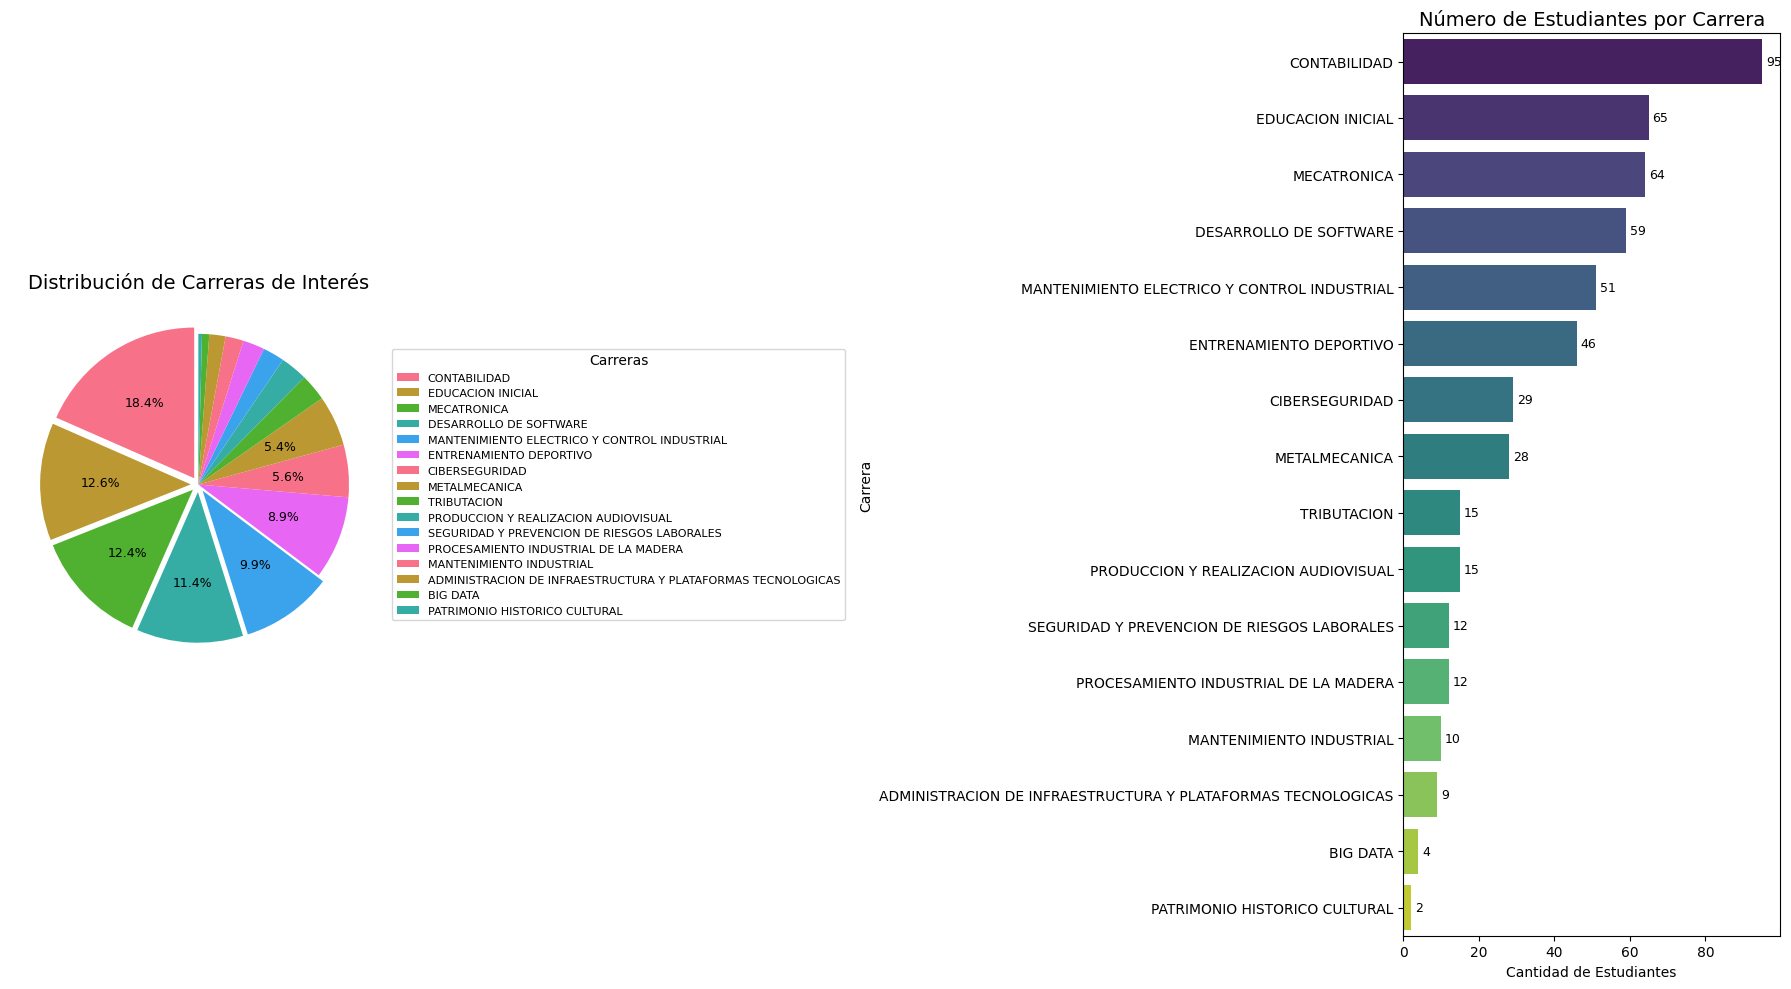

In [ ]:
# Contar las carreras
carrera_counts = df_clean['carrera_interes'].value_counts()

plt.figure(figsize=(18, 10))  # Ampliamos el tamaño

# Gráfico de pastel SIN etiquetas
plt.subplot(1, 2, 1)
plt.pie(
    carrera_counts.values,
    labels=None,  # ← Quita los nombres
    autopct=lambda p: '{:.1f}%'.format(p) if p > 5 else '',
    startangle=90,
    textprops={'fontsize': 9},
    explode=[0.05 if i < 5 else 0 for i in range(len(carrera_counts))]
)
plt.title('Distribución de Carreras de Interés', fontsize=14)
plt.legend(carrera_counts.index, title='Carreras', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Gráfico de barras
plt.subplot(1, 2, 2)
ax = sns.countplot(data=df_clean, y='carrera_interes', order=carrera_counts.index, palette='viridis')

plt.title('Número de Estudiantes por Carrera', fontsize=14)
plt.xlabel('Cantidad de Estudiantes')
plt.ylabel('Carrera')

# Etiquetas de cantidad
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2,
            f'{int(width)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


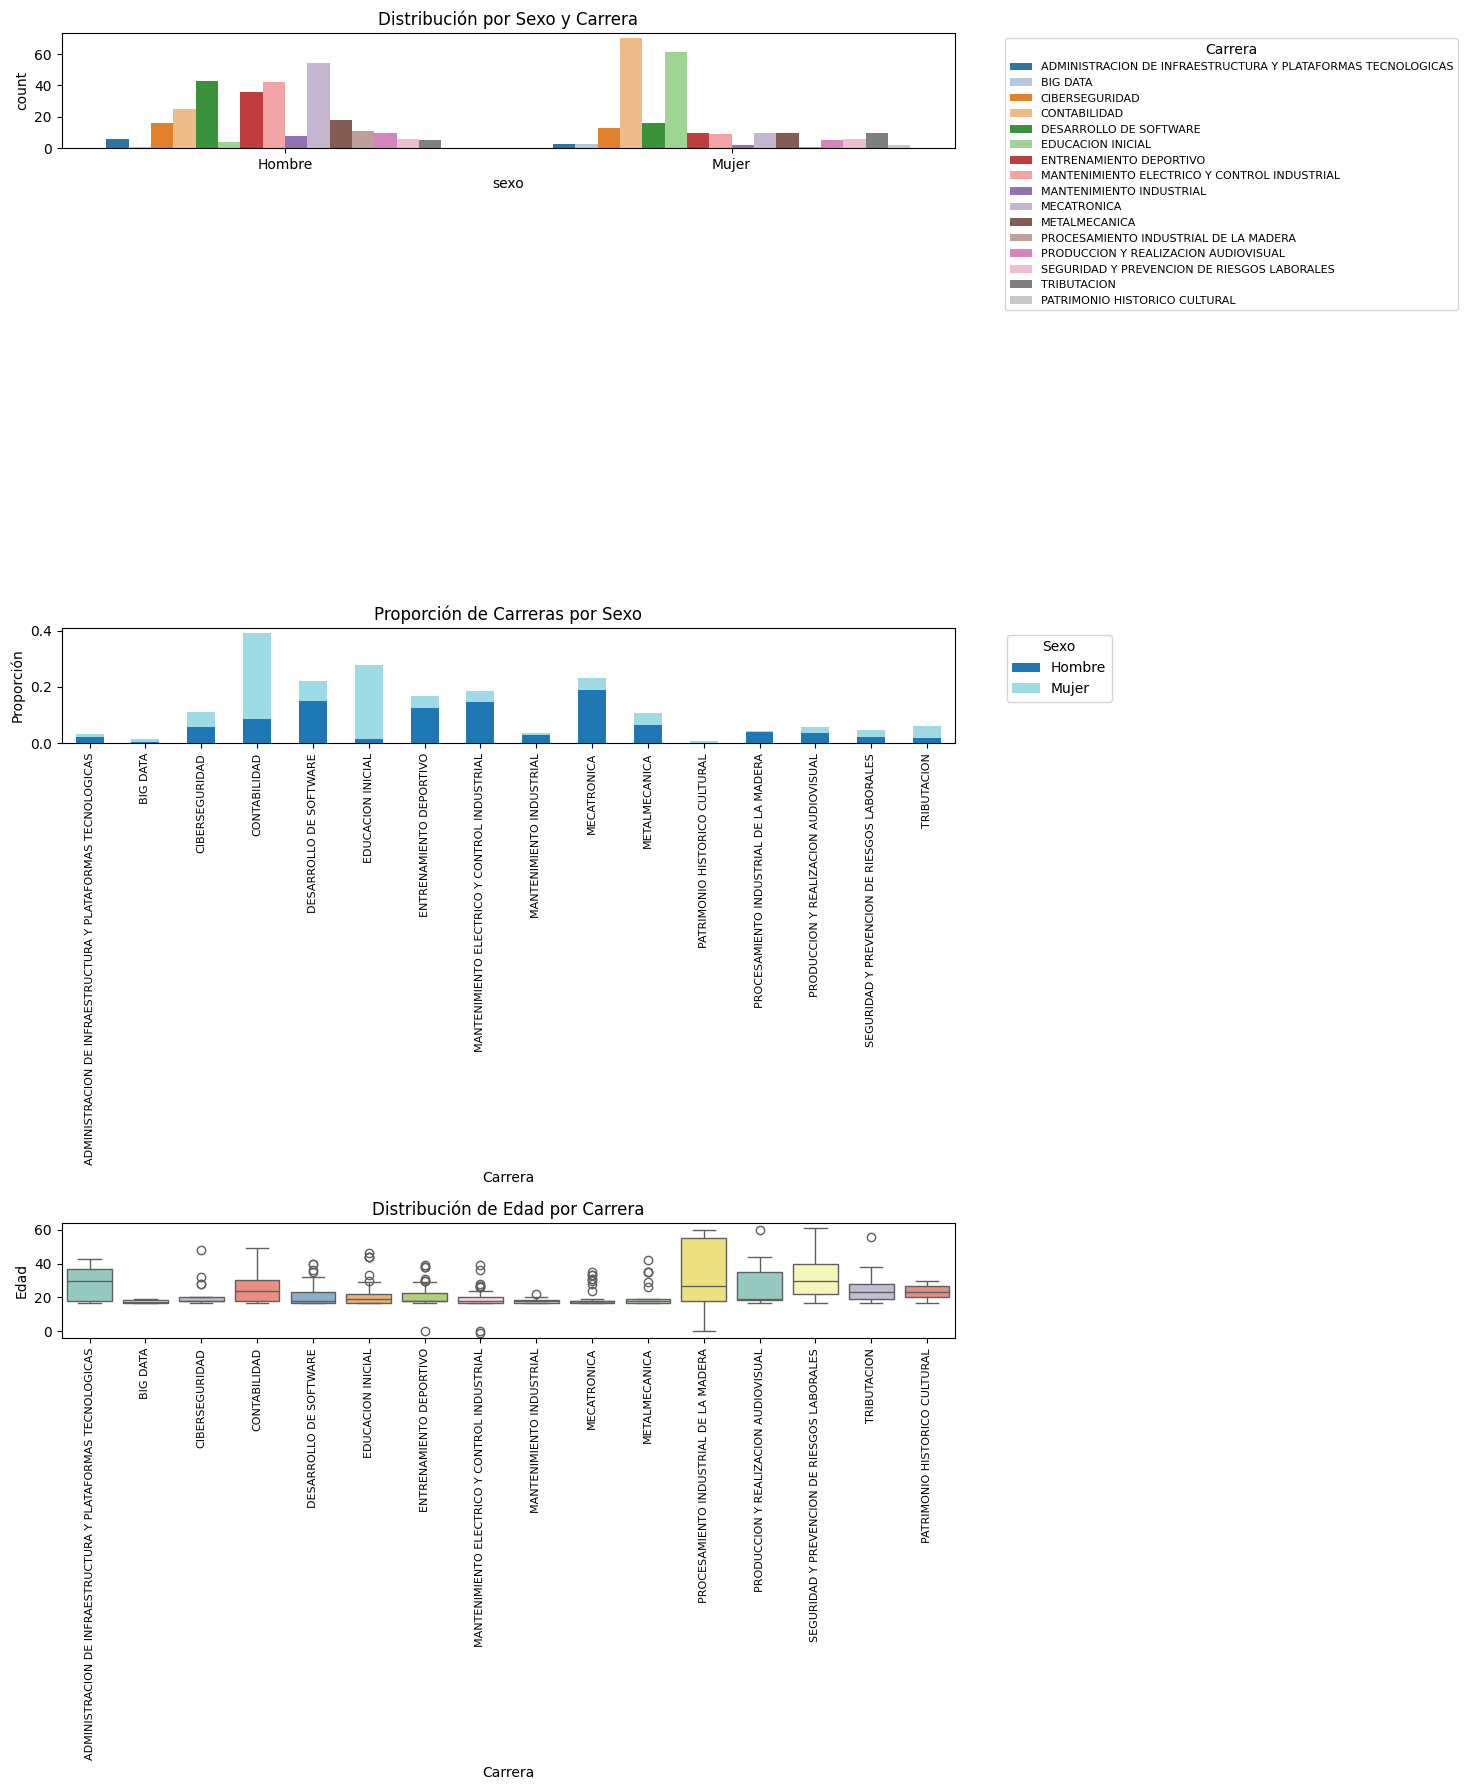

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparar conteos
crosstab_sexo = pd.crosstab(df_clean['sexo'], df_clean['carrera_interes'], normalize='index')

# Crear figura
plt.figure(figsize=(15, 18))  # Más alto para 3 filas

# Gráfico 1: Conteo por sexo y carrera
plt.subplot(3, 1, 1)
sns.countplot(data=df_clean, x='sexo', hue='carrera_interes', palette='tab20')
plt.title('Distribución por Sexo y Carrera')
plt.xticks(rotation=0)
plt.legend(title='Carrera', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Gráfico 2: Proporción de carreras por sexo
plt.subplot(3, 1, 2)
crosstab_sexo.T.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
plt.title('Proporción de Carreras por Sexo')
plt.ylabel('Proporción')
plt.xlabel('Carrera')
plt.xticks(rotation=90, fontsize=8)
plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')

# Gráfico 3: Boxplot de edad por carrera
plt.subplot(3, 1, 3)
sns.boxplot(data=df_clean, x='carrera_interes', y='edad', palette='Set3')
plt.title('Distribución de Edad por Carrera')
plt.xlabel('Carrera')
plt.ylabel('Edad')
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()


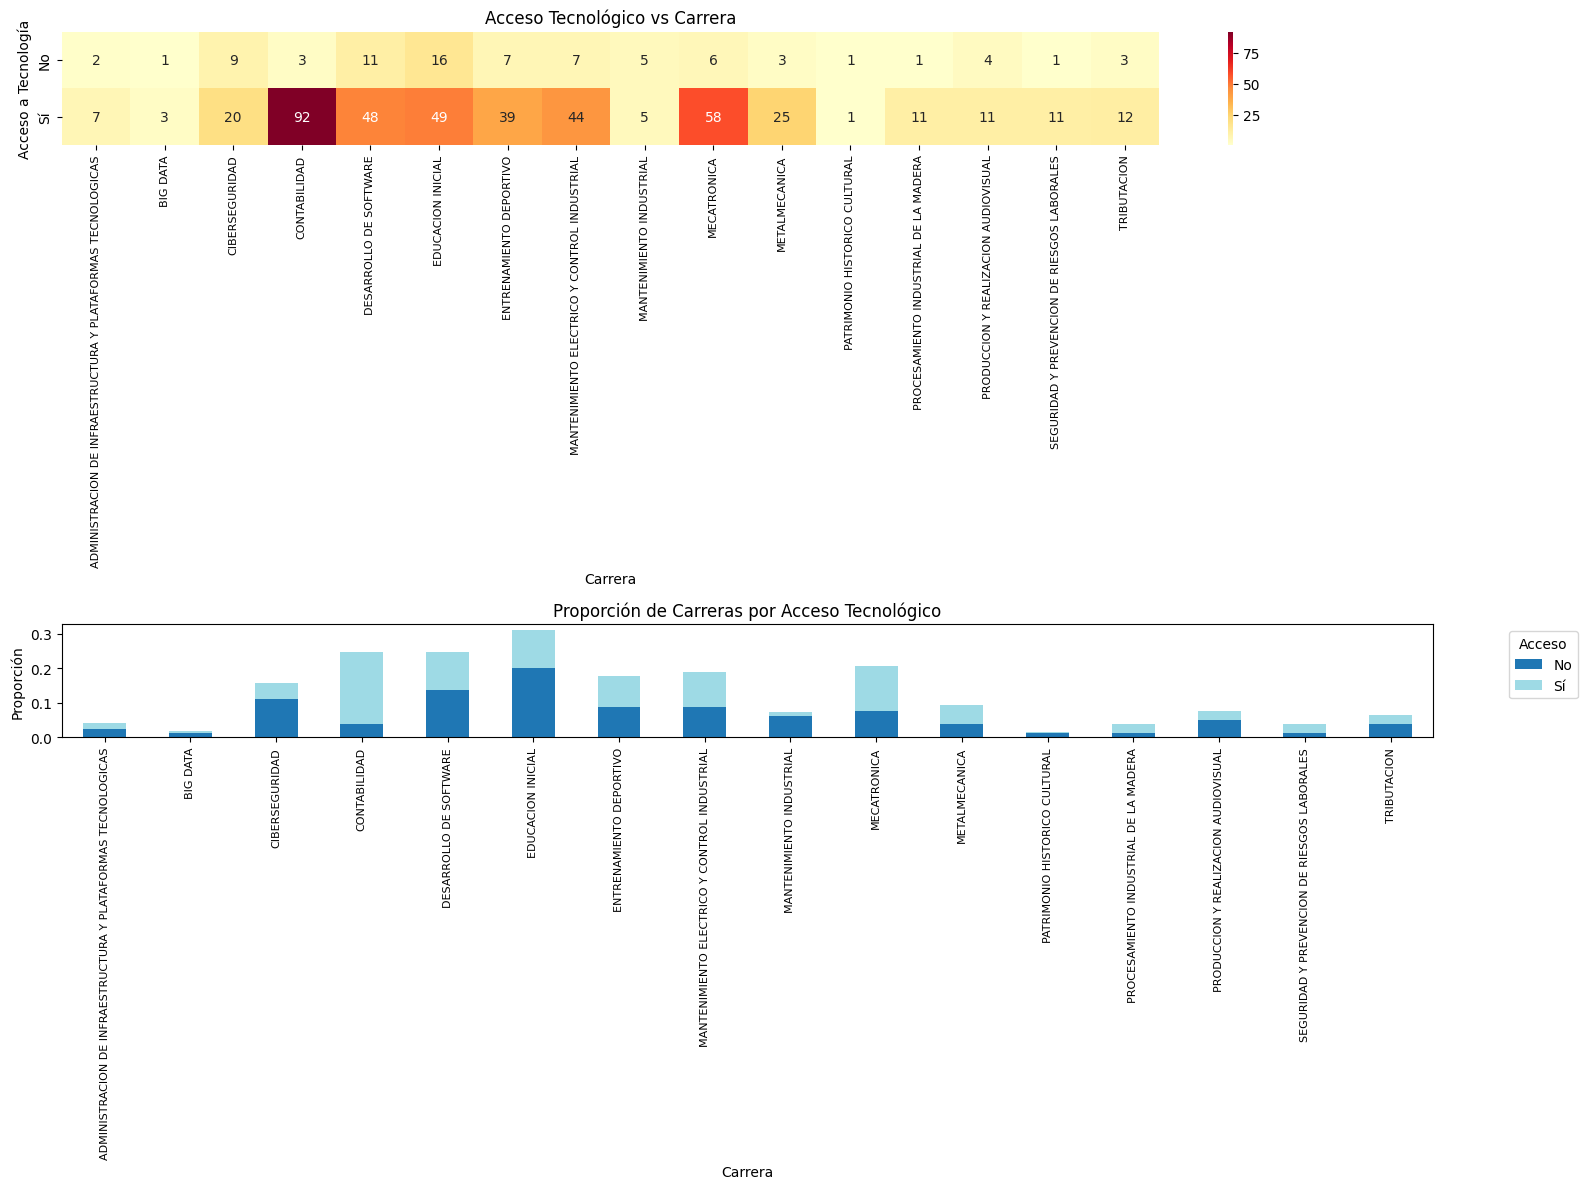

In [ ]:
# Tabla de frecuencia absoluta
crosstab_tech = pd.crosstab(df_clean['acceso_tecnologia'], df_clean['carrera_interes'])

# Tabla de proporciones normalizada por acceso
crosstab_tech_norm = pd.crosstab(df_clean['acceso_tecnologia'], df_clean['carrera_interes'], normalize='index')

# Crear figura
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 12))

# Gráfico 1: Heatmap de conteo
sns.heatmap(crosstab_tech, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Acceso Tecnológico vs Carrera')
axes[0].set_xlabel('Carrera')
axes[0].set_ylabel('Acceso a Tecnología')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

# Gráfico 2: Proporciones normalizadas
crosstab_tech_norm.T.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Proporción de Carreras por Acceso Tecnológico')
axes[1].set_ylabel('Proporción')
axes[1].set_xlabel('Carrera')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].legend(title='Acceso', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [16]:
df_clean['carrera_interes'].value_counts()

,count
carrera_interes,
CONTABILIDAD,95
EDUCACION INICIAL,65
MECATRONICA,64
DESARROLLO DE SOFTWARE,59
MANTENIMIENTO ELECTRICO Y CONTROL INDUSTRIAL,51
ENTRENAMIENTO DEPORTIVO,46
CIBERSEGURIDAD,29
METALMECANICA,28
TRIBUTACION,15


# FASE 5: MODELING - PREPARACIÓN PARA MACHINE LEARNING

In [28]:
# Agrupar carreras poco frecuentes en una categoría "OTRAS"
rare_classes = df_clean['carrera_interes'].value_counts()[df_clean['carrera_interes'].value_counts() < 20].index
df_clean['carrera_interes'] = df_clean['carrera_interes'].apply(lambda x: 'OTRAS' if x in rare_classes else x)


In [29]:
# Crear copia para trabajar
df_eng = df_clean.copy()

# 1. Agrupación inteligente de carreras por área
carreras_tech = ['DESARROLLO DE SOFTWARE', 'BIG DATA', 'CIBERSEGURIDAD',
                'ADMINISTRACION DE INFRAESTRUCTURA Y PLATAFORMAS TECNOLOGICAS']
carreras_ing = ['MECATRONICA', 'METALMECANICA', 'MANTENIMIENTO ELECTRICO Y CONTROL INDUSTRIAL',
               'MANTENIMIENTO INDUSTRIAL', 'PROCESAMIENTO INDUSTRIAL DE LA MADERA']
carreras_admin = ['CONTABILIDAD', 'TRIBUTACION', 'SEGURIDAD Y PREVENCION DE RIESGOS LABORALES']
carreras_social = ['EDUCACION INICIAL', 'ENTRENAMIENTO DEPORTIVO']
carreras_creativa = ['PRODUCCION Y REALIZACION AUDIOVISUAL']


# Función para clasificar área de carrera
area_mapping = {}
for carrera in carreras_tech:
    area_mapping[carrera] = 'Tecnología'
for carrera in carreras_ing:
    area_mapping[carrera] = 'Ingeniería'
for carrera in carreras_admin:
    area_mapping[carrera] = 'Administrativo'
for carrera in carreras_social:
    area_mapping[carrera] = 'Social'
for carrera in carreras_creativa:
    area_mapping[carrera] = 'Creativo'

df_eng['area_carrera'] = df_eng['carrera_interes'].map(area_mapping).fillna('Otro')

print("Distribución por área de carrera:")
print(df_eng['area_carrera'].value_counts())


Distribución por área de carrera:
area_carrera
Ingeniería        143
Social            111
Administrativo     95
Tecnología         88
Otro               79
Name: count, dtype: int64


# PARTE 2: AGRUPACIÓN DE CARRERAS MINORITARIAS

In [20]:
# Identificar carreras con pocas muestras
carrera_counts = df_eng['carrera_interes'].value_counts()
print("\nDistribución original de carreras:")
print(carrera_counts)

# Agrupar carreras con menos de 5 muestras
carreras_minoritarias = carrera_counts[carrera_counts < 5].index.tolist()
print(f"\nCarreras minoritarias a agrupar: {carreras_minoritarias}")

df_eng['carrera_agrupada'] = df_eng['carrera_interes'].apply(
    lambda x: 'CARRERA_MINORITARIA' if x in carreras_minoritarias else x
)

print("\nDistribución después de agrupar:")
print(df_eng['carrera_agrupada'].value_counts())


Distribución original de carreras:
carrera_interes
CONTABILIDAD                                    95
OTRAS                                           79
EDUCACION INICIAL                               65
MECATRONICA                                     64
DESARROLLO DE SOFTWARE                          59
MANTENIMIENTO ELECTRICO Y CONTROL INDUSTRIAL    51
ENTRENAMIENTO DEPORTIVO                         46
CIBERSEGURIDAD                                  29
METALMECANICA                                   28
Name: count, dtype: int64

Carreras minoritarias a agrupar: []

Distribución después de agrupar:
carrera_agrupada
CONTABILIDAD                                    95
OTRAS                                           79
EDUCACION INICIAL                               65
MECATRONICA                                     64
DESARROLLO DE SOFTWARE                          59
MANTENIMIENTO ELECTRICO Y CONTROL INDUSTRIAL    51
ENTRENAMIENTO DEPORTIVO                         46
CIBERSEGURIDAD    

# PARTE 3: NUEVAS CARACTERÍSTICAS DERIVADAS

In [21]:
# Perfil tecnológico
df_eng['perfil_tecnologico'] = 'Bajo'
df_eng.loc[df_eng['acceso_tecnologia'] == 'Si', 'perfil_tecnologico'] = 'Medio'
df_eng.loc[(df_eng['acceso_tecnologia'] == 'Si') & (df_eng['edad'] <= 25), 'perfil_tecnologico'] = 'Alto'
df_eng.loc[(df_eng['acceso_tecnologia'] == 'Si') & (df_eng['edad'] <= 25) &
           (df_eng['sexo'] == 'Masculino'), 'perfil_tecnologico'] = 'Alto'

print("Distribución perfil tecnológico:")
print(df_eng['perfil_tecnologico'].value_counts())

# Nivel socioeconómico inferido
df_eng['nivel_socioeconomico'] = 'Bajo'
mask_medio = (df_eng['acceso_tecnologia'] == 'Si') | (df_eng['enfermedad_catastrofica'] == 'No')
mask_alto = (df_eng['acceso_tecnologia'] == 'Si') & (df_eng['enfermedad_catastrofica'] == 'No') & (df_eng['tiene_discapacidad'] == 'No')

df_eng.loc[mask_medio, 'nivel_socioeconomico'] = 'Medio'
df_eng.loc[mask_alto, 'nivel_socioeconomico'] = 'Alto'

print("Distribución nivel socioeconómico:")
print(df_eng['nivel_socioeconomico'].value_counts())

# Agrupación de cantones
cantones_principales = df_eng['canton_nacimiento'].value_counts().head(5).index.tolist()
df_eng['canton_principal'] = df_eng['canton_nacimiento'].apply(
    lambda x: x if x in cantones_principales else 'Otro_Canton'
)

print("Cantones principales:")
print(df_eng['canton_principal'].value_counts())

# Categoría de edad detallada
df_eng['categoria_edad_detallada'] = 'Adulto'
df_eng.loc[df_eng['edad'] <= 17, 'categoria_edad_detallada'] = 'Adolescente'
df_eng.loc[(df_eng['edad'] > 17) & (df_eng['edad'] <= 22), 'categoria_edad_detallada'] = 'Joven_Temprano'
df_eng.loc[(df_eng['edad'] > 22) & (df_eng['edad'] <= 27), 'categoria_edad_detallada'] = 'Joven_Tardio'
df_eng.loc[(df_eng['edad'] > 27) & (df_eng['edad'] <= 35), 'categoria_edad_detallada'] = 'Adulto_Joven'

print("Distribución categoría edad detallada:")
print(df_eng['categoria_edad_detallada'].value_counts())

Distribución perfil tecnológico:
perfil_tecnologico
Bajo    516
Name: count, dtype: int64
Distribución nivel socioeconómico:
nivel_socioeconomico
Medio    506
Bajo      10
Name: count, dtype: int64
Cantones principales:
canton_principal
Otro_Canton    190
Cuenca         144
Cuenca         122
Azuay           29
Azuay           19
CUENCA          12
Name: count, dtype: int64
Distribución categoría edad detallada:
categoria_edad_detallada
Joven_Temprano    209
Adolescente       142
Adulto_Joven       58
Joven_Tardio       57
Adulto             50
Name: count, dtype: int64


# PARTE 4: PREPARACIÓN DE DATOS PARA MODELADO

In [22]:
# Selección de características mejoradas
feature_columns_mejoradas = [
    'edad', 'sexo', 'estado_civil', 'etnia', 'tiene_discapacidad',
    'enfermedad_catastrofica', 'acceso_tecnologia',
    'grupo_edad', 'generacion', 'perfil_tecnologico',
    'nivel_socioeconomico', 'canton_principal', 'categoria_edad_detallada',
    'area_carrera'
]

# Verificar características disponibles
available_features = [col for col in feature_columns_mejoradas if col in df_eng.columns]
print(f"\nCaracterísticas disponibles: {len(available_features)}")
print(available_features)

# Dataset para modelado
df_model = df_eng[available_features + ['carrera_agrupada']].copy()
df_model = df_model.dropna(subset=['carrera_agrupada'])

print(f"\nMuestras para modelado: {len(df_model)}")
print(f"Características: {len(available_features)}")

# Separar características y variable objetivo
X = df_model[available_features]
y = df_model['carrera_agrupada']

# Identificar tipos de variables
numeric_features = ['edad']
categorical_features = [col for col in available_features if col not in numeric_features]

print(f"\nCaracterísticas numéricas: {numeric_features}")
print(f"Características categóricas: {len(categorical_features)}")



Características disponibles: 14
['edad', 'sexo', 'estado_civil', 'etnia', 'tiene_discapacidad', 'enfermedad_catastrofica', 'acceso_tecnologia', 'grupo_edad', 'generacion', 'perfil_tecnologico', 'nivel_socioeconomico', 'canton_principal', 'categoria_edad_detallada', 'area_carrera']

Muestras para modelado: 516
Características: 14

Características numéricas: ['edad']
Características categóricas: 13


# PARTE 5: PREPROCESAMIENTO Y DIVISIÓN DE DATOS

In [23]:
# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {len(X_train)}")
print(f"Datos de prueba: {len(X_test)}")
print(f"Distribución en entrenamiento:")
print(pd.Series(y_train).value_counts())


Datos de entrenamiento: 387
Datos de prueba: 129
Distribución en entrenamiento:
carrera_agrupada
CONTABILIDAD                                    71
OTRAS                                           59
EDUCACION INICIAL                               49
MECATRONICA                                     48
DESARROLLO DE SOFTWARE                          44
MANTENIMIENTO ELECTRICO Y CONTROL INDUSTRIAL    38
ENTRENAMIENTO DEPORTIVO                         35
CIBERSEGURIDAD                                  22
METALMECANICA                                   21
Name: count, dtype: int64


# PARTE 6: DEFINICIÓN DE MODELOS


In [30]:
# Crear diccionario de modelos optimizados
models_optimized = {
    'Random Forest Optimizado': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),

    'Gradient Boosting Optimizado': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),

    'Logistic Regression Balanceada': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=0.5,
        random_state=42
    ),

    'SVM Optimizado': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),

    'K-Neighbors': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='manhattan'
    )
}

print(f"Modelos definidos: {len(models_optimized)}")

Modelos definidos: 6


# PARTE 7: ENTRENAMIENTO CON BALANCEO DE CLASES

In [33]:
# Configuración de validación cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar resultados
results_mejorados = {}

print("Iniciando entrenamiento de modelos...")
print("="*50)

# Entrenar cada modelo
for name, model in models_optimized.items():
    print(f"\n Entrenando {name}...")

    try:
        # Pipeline con balanceo SMOTE
        pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('balancer', SMOTE(random_state=42, k_neighbors=3)),
            ('classifier', model)
        ])

        # Validación cruzada con balanced_accuracy
        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv_strategy, scoring='balanced_accuracy', n_jobs=-1
        )

        # Entrenamiento final
        pipeline.fit(X_train, y_train)

        # Predicciones en test
        y_pred = pipeline.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        # Almacenar resultados
        results_mejorados[name] = {
            'pipeline': pipeline,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_accuracy': test_accuracy,
            'balanced_accuracy': balanced_acc,
            'predictions': y_pred
        }

        print(f"   CV Balanced Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
        print(f"   Test Accuracy: {test_accuracy:.3f}")
        print(f"   Balanced Accuracy: {balanced_acc:.3f}")

    except Exception as e:
        print(f" Error: {str(e)}")
        continue

print(f"\nEntrenamiento completado. Modelos exitosos: {len(results_mejorados)}")


Iniciando entrenamiento de modelos...

 Entrenando Random Forest Optimizado...
   CV Balanced Accuracy: 0.641 (±0.037)
   Test Accuracy: 0.783
   Balanced Accuracy: 0.725

 Entrenando Gradient Boosting Optimizado...
   CV Balanced Accuracy: 0.627 (±0.037)
   Test Accuracy: 0.767
   Balanced Accuracy: 0.686

 Entrenando Extra Trees...
   CV Balanced Accuracy: 0.643 (±0.043)
   Test Accuracy: 0.791
   Balanced Accuracy: 0.741

 Entrenando Logistic Regression Balanceada...
   CV Balanced Accuracy: 0.667 (±0.025)
   Test Accuracy: 0.729
   Balanced Accuracy: 0.658

 Entrenando SVM Optimizado...
   CV Balanced Accuracy: 0.651 (±0.030)
   Test Accuracy: 0.767
   Balanced Accuracy: 0.723

 Entrenando K-Neighbors...
   CV Balanced Accuracy: 0.567 (±0.046)
   Test Accuracy: 0.682
   Balanced Accuracy: 0.613

Entrenamiento completado. Modelos exitosos: 6


In [34]:
# Seleccionar el mejor modelo (Extra Trees en este caso)
mejor_modelo = results_mejorados['Extra Trees']['pipeline']

# Guardar el modelo
import joblib
joblib.dump(mejor_modelo, 'mejor_modelo_prediccion.pkl')
print("Modelo guardado como 'mejor_modelo_prediccion.pkl'")

Modelo guardado como 'mejor_modelo_prediccion.pkl'
